In [1]:
using CSV
using DataFrames
using Dates

In [2]:
# Cargar el CSV en un DataFrame
df = CSV.read("masacres_2026_colombia_indepaz.csv", DataFrame)

Row,Nº,Fecha,Departamento,Municipio,Nº de Víctimas
,Int64,String15,String31,String31,Int64
1,1,03/01/2026,Cauca,Santander De Quilichao,3
2,2,06/01/2026,Norte de Santander,Cúcuta,3
3,3,06/01/2026,Antioquia,Amalfi,4
4,4,09/01/2026,La Guajira,Maicao,5
5,5,10/01/2026,Antioquia,Abejorral,3
6,6,15/01/2026,Valle del Cauca,Ansermanuevo,3
7,7,16/01/2026,Guaviare,El Retorno,26
8,8,16/01/2026,Meta,Granada,3
9,9,18/01/2026,Cauca,Padilla,4


In [3]:
describe(df)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,Nº,45.0,1,45.0,89,0,Int64
2,Fecha,,01/02/2026,,31/01/2026,0,String15
3,Departamento,,Antioquia,,Vichada,0,String31
4,Municipio,,Abejorral,,Ábrego,0,String31
5,Nº de Víctimas,3.77528,3,3.0,26,0,Int64


In [4]:
# Convertir la columna "Fecha" a tipo Date usando el formato dd/mm/yyyy
df.Fecha = Date.(df.Fecha, dateformat"dd/mm/yyyy")

# Crear una columna con el periodo del mes (formato "YYYY-MM")
df.Mes = Dates.format.(df.Fecha, "yyyy-mm")

# Agrupar por mes y calcular la suma de víctimas (y conteo de eventos)
df_mensual = combine(
    groupby(df, :Mes),
    Symbol("Nº de Víctimas") => sum => :Total_Victimas,
    nrow => :Num_Masacres
)

Row,Mes,Total_Victimas,Num_Masacres
,String,Int64,Int64
1,2026-01,66,13
2,2026-02,28,9
3,2026-03,42,14
4,2026-04,70,14
5,2026-05,39,10
6,2026-06,30,9
7,2026-07,25,8
8,2026-08,27,9
9,2026-09,9,3


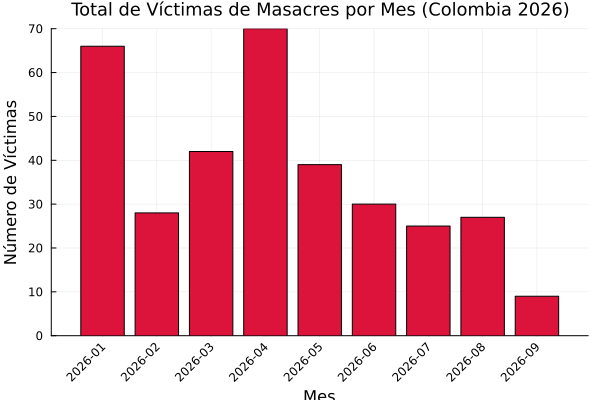

In [6]:
using Plots

bar(
    df_mensual.Mes,
    df_mensual.Total_Victimas,
    title = "Total de Víctimas de Masacres por Mes (Colombia 2026)",
    titlefontsize = 12,
    xlabel = "Mes",
    ylabel = "Número de Víctimas",
    legend = false,
    xrotation = 45,
    color = :crimson,
    yticks = 0:10:80
)

In [8]:
savefig("victimas_masacres_2026.png");
savefig("victimas_masacres_2026.pdf");